In [1]:
#TODO modelnet10 needs vector

In [2]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "bigger_emnist"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}



architecture = default_architecutre_mapping[dataset]
budget = None

In [3]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [4]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

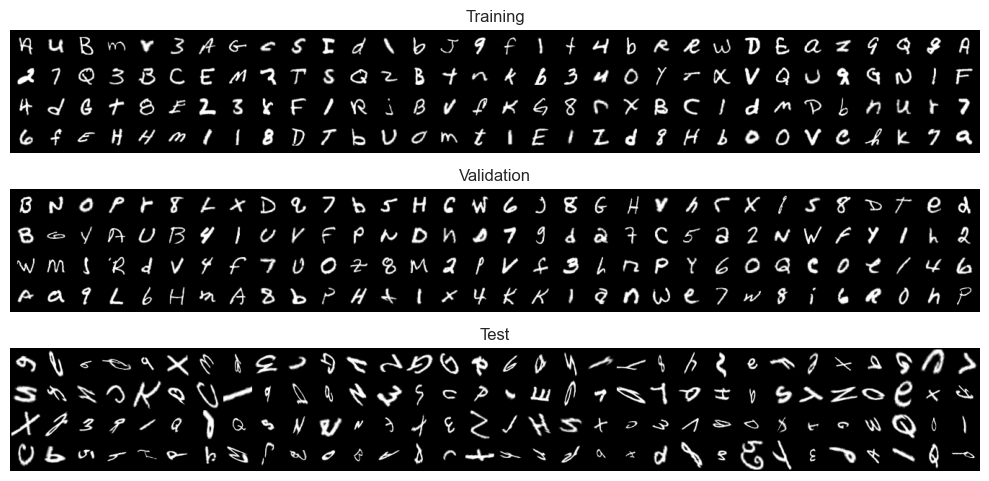

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
x = next(iter(test_loader_transformed))[0]

batch_size = next(iter(train_loader))[0].shape[0]

from utils.eval.vis import vis_dataset

vis_dataset(train_loader, val_loader, test_loader_transformed)
from experiment_thesis.main import train_and_get_model, train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture,
                                "comparison_unsupervised")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path, transform_name, f"{safe}.json")

In [6]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_emnist_bigger_extended_resnet_small.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [7]:
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [8]:
#check main model
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)
res = evaluate_base_model(model, test_loader, device)
print(res)

{'accuracy': 0.1709042489528656, 'f2_macro': 0.16747358441352844, 'f2_micro': 0.1709042489528656, 'f2_weighted': 0.16747358441352844}


{'accuracy': 0.8843085169792175, 'f2_macro': 0.8837493062019348, 'f2_micro': 0.8843085169792175, 'f2_weighted': 0.8837493062019348}


In [9]:
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]


from utils.replacer import replace_rotation_transforms_2vec

from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)

if dataset == "modelnet10":
    transform_seq = replace_rotation_transforms_2vec(transform_seq)

In [10]:
print(transform_seq.transformations)

[<utils.transforms.rotation.Rotation2D object at 0x0000023D11318D30>, <utils.transforms.shear.DirectedShear object at 0x0000023D11875D80>, <utils.transforms.shear.DirectedShear object at 0x0000023D11875DE0>, <utils.transforms.scale.DirectedScale object at 0x0000023D11874D30>, <utils.transforms.scale.DirectedScale object at 0x0000023D11874D90>]


In [11]:
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic
make_deterministic(model)



In [12]:
from experiment_thesis.dataset_preperation.get_dataset import get_layer_embedding_cache_config,create_layer_embedding_cache
cache_config = get_layer_embedding_cache_config(dataset, architecture,transform_name=None,dataset_info=dataset_info)
train_cache =create_layer_embedding_cache(model, train_loader_no_shuffle,cache_config, embedding_cache_path, device=device)


In [13]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [14]:
from experiment_thesis.ood import base_prepare

base_prepare.OOD_PARAM_SAMPLERS.keys()

dict_keys(['energy', 'energy_ts', 'max_logit', 'entropy', 'max_softmax', 'differentiable_max_softmax', 'adjusted_entropy', 'cross_entropy', 'ash', 'gradnorm', 'laplace_prob', 'laplace_energy', 'laplace_variance', 'laplace_mutual_information', 'laplace_entropy_plus_mi', 'laplace_entropy', 'laplace_weighted', 'laplace_mi', 'laplace_best_criterion', 'laplace_entropy_gridsearch', 'mc_dropout_prob', 'mc_dropout_variance', 'mc_dropout_mi', 'mc_dropout_energy', 'mc_dropout_last_layer_prob', 'mc_dropout_last_layer_variance', 'mc_dropout_last_layer_mi', 'mc_dropout_last_layer_energy', 'mc_batchnorm_prob', 'mc_batchnorm_variance', 'mc_batchnorm_mi', 'mc_batchnorm_energy', 'mc_dropout_best_criterion', 'mc_batchnorm_best_criterion', 'mc_dropout_last_layer_best_criterion', 'react', 'react_all', 'dice', 'gaussian', 'gmm', 'gram', 'kde', 'kl_matching', 'faiss_knn', 'faiss_per_class_knn', 'knn', 'per_class_knn', 'knn_trap', 'per_class_knn_trap', 'knn_mixed', 'per_class_knn_mixed', 'knn_mahalanobis', '

In [15]:
detectors = ["knn","per_class_knn", "knn_mixed","per_class_knn_mixed","knn_mixed_faiss","knn_itf","vim","react","dice","ash","she","laplace_mi","laplace_energy","laplace_weighted","trust_score","openmax","mahalanobis","rmd","class_prototype","react_all","energy","per_class_prototype","single_mahalanobis","single_rmd","single_mahalanobis_individual","single_rmd_individual","mahalanobis_individual","rmd_individual","prototype_multi", "laplace_entropy","adjusted_entropy","nn_guided","nn_guided_one"]
#dont do kde to expensive, and not better.
#global protoype makes no sense over class based protoype
# lof fit is to slow, gmm is even slower or fails due to size
# gram runs out of main memory,

detectors_parameterless = ["energy_ts","entropy","kl_matching","laplace_entropy_gridsearch"]
detectors = detectors + detectors_parameterless
from experiment_thesis.dataset_preperation.basic_networks import FlexibleResNet
if not isinstance(model,FlexibleResNet):
    #remove ash and react_all as they only work with resnets
    detectors.remove("ash")
    detectors.remove("react_all")
    if "react" not in detectors:
        detectors.append("react")
    detectors.append("ash_last")



In [16]:
# python
import os
import json
import math
import torch
from typing import Tuple, Optional, Any, Dict

from experiment_thesis.ood.base_prepare import create_ood_problem, get_default_ood_params

def find_best_detector_and_instantiate(
    base_results_dir: str,
    detectors: list,
    model,
    train_cache,
    transform_seq_arg,
    dataset_info,
    architecture: str,
    device,
    val_id_loader,
    val_ood_loader,
    prefer_second: Optional[str] = None,
) -> Tuple[
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
]:
    """
    Find best detector by recorded `accuracy_mean` (preferring mean) and instantiate its OOD problem.
    Returns:
      (best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict)
    where score dict is `{"mean": float, "se": float}` (values may be math.nan if missing).
    """

    def _load_score(det_name: str) -> Optional[Dict[str, float]]:
        eval_path = os.path.join(base_results_dir, det_name, "eval_results.json")
        eval_default_path = os.path.join(base_results_dir, det_name, "eval_results_default.json")

        for p in (eval_path, eval_default_path):
            if os.path.exists(p):
                try:
                    with open(p, "r") as f:
                        data = json.load(f)
                except Exception:
                    continue
                mean = data.get("accuracy_mean")
                se = data.get("accuracy_se", data.get("accuracy_std"))  # prefer se, fall back to std
                # normalize types
                mean_val = float(mean) if isinstance(mean, (int, float)) else math.nan
                se_val = float(se) if isinstance(se, (int, float)) else math.nan
                if not math.isnan(mean_val):
                    return {"mean": mean_val, "se": se_val}
        return None

    # 1) scan detectors for optimized accuracy (use mean)
    best_detector: Optional[str] = None
    best_score_val = -math.inf
    best_score_dict: Optional[Dict[str, float]] = None
    for det in detectors:
        score_dict = _load_score(det)
        if score_dict is None:
            continue
        mean = score_dict["mean"]
        if mean > best_score_val:
            best_score_val = mean
            best_detector = det
            best_score_dict = score_dict

    # If we didn't find any valid scored detector, return Nones
    if best_detector is None:
        return None, None, None, None, None, None

    # 2) load best params for best_detector (or default if no params file)
    det_dir = os.path.join(base_results_dir, best_detector)
    params_path = os.path.join(det_dir, "best_params.json")
    best_params = None
    if os.path.exists(params_path):
        try:
            with open(params_path, "r") as f:
                best_params = json.load(f)
        except Exception:
            best_params = None

    if best_params is None:
        best_params = get_default_ood_params(best_detector)

    # 3) try load saved model states for this detector (if any)
    best_model_params = []
    prefix = os.path.join(det_dir, "best_model")
    i = 0
    while os.path.exists(f"{prefix}_{i}.pt"):
        try:
            best_model_params.append(torch.load(f"{prefix}_{i}.pt", map_location="cpu"))
        except Exception:
            pass
        i += 1

    final_kwargs = {
        "model": model,
        "train_cache": train_cache,
        "transform_seq": transform_seq_arg,
        "dataset_info": dataset_info,
        "architecture": architecture,
        "device": str(device),
        "val_id_loader": val_id_loader,
        "val_ood_loader": val_ood_loader,
    }
    if best_model_params:
        final_kwargs["model_params"] = best_model_params

    best_problem = create_ood_problem(best_detector, best_params, **final_kwargs)

    # 4) prepare the second problem: choose the better of energy vs entropy by recorded performance
    if prefer_second and prefer_second in detectors:
        second_choice = prefer_second
        second_score_dict = _load_score(second_choice)
    else:
        candidates = [d for d in ("energy", "entropy") if d in detectors]
        second_choice = None
        best_cand_val = -math.inf
        second_score_dict = None
        for c in candidates:
            sdict = _load_score(c)
            if sdict is not None and sdict["mean"] > best_cand_val:
                best_cand_val = sdict["mean"]
                second_choice = c
                second_score_dict = sdict

    # avoid selecting same detector twice
    if second_choice == best_detector:
        other = "entropy" if best_detector == "energy" else "energy"
        if other in detectors:
            other_score = _load_score(other)
            if other_score is not None:
                second_choice = other
                second_score_dict = other_score
            else:
                second_choice = None
                second_score_dict = None
        else:
            second_choice = None
            second_score_dict = None

    if second_choice is None:
        second_problem = None
    else:
        det2_dir = os.path.join(base_results_dir, second_choice)
        params2_path = os.path.join(det2_dir, "best_params.json")
        params2 = None
        if os.path.exists(params2_path):
            try:
                with open(params2_path, "r") as f:
                    params2 = json.load(f)
            except Exception:
                params2 = None
        if params2 is None:
            params2 = get_default_ood_params(second_choice)

        model_params2 = []
        prefix2 = os.path.join(det2_dir, "best_model")
        j = 0
        while os.path.exists(f"{prefix2}_{j}.pt"):
            try:
                model_params2.append(torch.load(f"{prefix2}_{j}.pt", map_location="cpu"))
            except Exception:
                pass
            j += 1

        final_kwargs2 = dict(final_kwargs)
        if model_params2:
            final_kwargs2["model_params"] = model_params2

        second_problem = create_ood_problem(second_choice, params2, **final_kwargs2)

    return best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict

# Example call (update unpacking to 6 values)
base_results_dir = os.path.join(
    current_path,
    "experiment_files",
    "results",
    "comparison_unsupervised",
    str(dataset),
    str(architecture),
    getattr(dataset_info, "transform_seq_name", "default"),
)

best_detector, best_problem, best_score, second_choice, second_problem, second_score = find_best_detector_and_instantiate(
    base_results_dir=base_results_dir,
    detectors=detectors,
    model=model,
    train_cache=train_cache,
    transform_seq_arg=transform_seq,
    dataset_info=dataset_info,
    architecture=architecture,
    device=device,
    val_id_loader=val_loader_transformed,
    val_ood_loader=val_loader_transformed,
)

In [17]:
from utils.transformation_problem import TransformationProblem
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search
from confidence.control.regression import RegressionConfidence, make_aggregator
from confidence.control.regression_wrapper import RegressionWrapper
from search.shgo import SHGO
optimizer = SHGO(initial_samples=46, local_runs=2, local_max_steps=3,local_opt_kwargs={"lr":0.1})

if dataset == "tu_berlin":
    optimizer = SHGO(initial_samples=60,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})





In [18]:
def get_final_weights(aggregator):
    if hasattr(aggregator, "combiner"):
        return aggregator.combiner.weight.data,aggregator.combiner.bias.data
    elif hasattr(aggregator, "linear"):
        return aggregator.linear.weight.data,aggregator.linear.bias.data
    else:
        return

def update_final_weights(aggregator, weights):
    if hasattr(aggregator, "combiner"):
        aggregator.combiner.weight.data = weights[0]
        aggregator.combiner.bias.data = weights[1]
    elif hasattr(aggregator, "linear"):
        aggregator.linear.weight.data = weights[0]
        aggregator.linear.bias.data = weights[1]
    else:
        return

In [19]:
from utils.eval.ood_performance import evaluate_confidence_and_search


In [20]:
import json
import os
import optuna

def run_aggregator_comparison(
    best_problem,
    second_problem,
    model,
    optimizer,
    transform_seq,
    val_loader,
    val_loader_transformed,
    test_loader_transformed,
    dataset_info,
    device,
    aggregator_kind: str = "flexible_monotonic",
    n_trials_opt: int = 10,
    verbose: bool = True,
) -> Dict[str, Any]:

    save_dir = os.path.join(
        current_path, "experiment_files", "results", dataset, architecture, "comparison_combined"
    )
    os.makedirs(save_dir, exist_ok=True)

    fitted_state_path = os.path.join(save_dir, f"{aggregator_kind}_fitted_state.pt")
    default_eval_path = os.path.join(save_dir, f"{aggregator_kind}_default.json")
    optuna_json_path = os.path.join(save_dir, f"{aggregator_kind}_optuna.json")
    optuna_state_path = os.path.join(save_dir, f"{aggregator_kind}_best_state.pt")
    optimized_eval_path = os.path.join(save_dir, f"{aggregator_kind}_optimized.json")

    conf1 = best_problem.confidence_module
    conf2 = second_problem.confidence_module

    dual_model = conf1.model
    conf_final = conf2.confidence
    conf_inter = conf1.confidence.confidence_trust
    sub_confs = [conf_inter, conf_final]
    k = len(sub_confs)

    aggregator = make_aggregator(k=k, kind=aggregator_kind).to(device)

    reg_conf = RegressionConfidence(
        sub_confs=sub_confs,
        aggregator=aggregator,
        input_selectors=list(range(k)),
        freeze_subs=True,
        scaler="standardize",
        lr=1e-1,
        epochs=1000,
    )
    final_conf = RegressionWrapper(dual_model, reg_conf).to(device)
    prob = TransformationProblem(final_conf, transform_seq, consolidate_method="consolidate_simple",max_batch_size=dataset_info.batch_size_search)

    # --- STEP 1: FIT OR LOAD ---
    if os.path.exists(fitted_state_path):
        if verbose:
            print(f"Loading fitted state from {fitted_state_path}")
        reg_conf.load_state_dict(torch.load(fitted_state_path, map_location=device))
        #print state dict weights
        print(torch.load(fitted_state_path, map_location=device))
        final_conf.eval()
        dual_model.eval()
    else:
        if verbose:
            print(f"Fitting {aggregator_kind} aggregator...")
        for p in [default_eval_path, optuna_json_path, optuna_state_path, optimized_eval_path]:
            if os.path.exists(p):
                os.remove(p)
        final_conf.fit(val_loader, val_loader_transformed)
        print(reg_conf.state_dict())
        torch.save(reg_conf.state_dict(), fitted_state_path)

    if verbose and not aggregator_kind == "mlp":
        w, b = get_final_weights(aggregator)
        print("\n--- FITTED AGGREGATOR WEIGHTS ---")
        print("W:", w)
        print("b:", b)
        print("\n--- VALIDATION PERFORMANCE (FITTED) ---")
        print(final_conf.evaluate(val_loader, val_loader_transformed))



    default_metrics = load_or_run_evaluate_confidence_and_search(
        model=model,
        optimizer=optimizer,
        problem=prob,
        test_loader=test_loader_transformed,
        save_path=default_eval_path,
        max_batch_override=dataset_info.batch_size_search,
        show_progress=True,
        repeats=5,
        return_per_run=False,
        overwrite=False,
        store_val=False,
        store_correct=False,
    )

    summary = {
        "aggregator_kind": aggregator_kind,
        "default_path": default_eval_path,
        "default_metrics": default_metrics,
        "fitted_state_path": fitted_state_path,
    }

    if aggregator_kind == "mlp":
        return summary

    if os.path.exists(optuna_json_path) and os.path.exists(optuna_state_path):
        try:
            with open(optuna_json_path, "r") as f:
                meta = json.load(f)
            reg_conf.load_state_dict(torch.load(optuna_state_path, map_location=device))
            summary["best_factors"] = meta.get("best_factors", [])
            summary["best_value"] = float(meta.get("best_value", float("nan")))
        except:
            os.remove(optuna_json_path)
            os.remove(optuna_state_path)

    if not (os.path.exists(optuna_json_path) and os.path.exists(optuna_state_path)):

        orig_state = {k: v.clone() if isinstance(v, torch.Tensor) else v
              for k, v in reg_conf.state_dict().items()}
        print(orig_state)
        study = optuna.create_study(direction="maximize")

        def objective(trial):
            factors = [trial.suggest_float(f"factor_{i}", 0.1, 10.0, log=True) for i in range(k)]
            with torch.no_grad():
                w, b = get_final_weights(aggregator)
                fac = torch.tensor(factors, dtype=w.dtype, device=w.device).view_as(w)
                update_final_weights(aggregator, (w * fac, b))

            result = evaluate_confidence_and_search(
                model, optimizer, prob, val_loader_transformed,
                max_batch_override=dataset_info.batch_size_search, show_progress=True, repeats=1
            )

            reg_conf.load_state_dict(orig_state)
            return result.get("accuracy_mean", result.get("accuracy"))

        study.optimize(objective, n_trials=n_trials_opt, show_progress_bar=False)

        best_factors = [study.best_trial.params[f"factor_{i}"] for i in range(k)]
        with torch.no_grad():
            w, b = get_final_weights(aggregator)
            fac = torch.tensor(best_factors, dtype=w.dtype, device=w.device).view_as(w)
            update_final_weights(aggregator, (w * fac, b))

        torch.save(reg_conf.state_dict(), optuna_state_path)
        with open(optuna_json_path, "w") as f:
            json.dump({"best_factors": best_factors, "best_value": float(study.best_value)}, f, indent=2)

        summary["best_factors"] = best_factors
        summary["best_value"] = float(study.best_value)

    if verbose and not aggregator_kind == "mlp":
        w, b = get_final_weights(aggregator)
        print("\n--- OPTIMIZED AGGREGATOR WEIGHTS ---")
        print("W:", w)
        print("b:", b)

    optimized_metrics = load_or_run_evaluate_confidence_and_search(
        model=model,
        optimizer=optimizer,
        problem=prob,
        test_loader=test_loader_transformed,
        save_path=optimized_eval_path,
        max_batch_override=dataset_info.batch_size_search,
        show_progress=True,
        repeats=5,
        return_per_run=False,
        overwrite=False,
        store_val=False,
        store_correct=False,
    )

    summary["optimized_path"] = optimized_eval_path
    summary["optimized_metrics"] = optimized_metrics

    if verbose:
        print("\n--- TEST METRICS (OPTIMIZED) ---")
        print(optimized_metrics)

    import gc
    gc.collect()
    torch.cuda.empty_cache()

    return summary


In [21]:

conf1 = best_problem.confidence_module
conf2 = second_problem.confidence_module












In [22]:
if hasattr(conf1.confidence,"confidence_final"):
    run_aggregator_comparison(
        best_problem,
        second_problem,
        model,
        optimizer,
        transform_seq,
        val_loader,
        val_loader_transformed,
        test_loader_transformed,
        dataset_info,
        device,
        aggregator_kind="linear",
        n_trials_opt=10,
        verbose=True,
    )

Loading fitted state from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_combined\linear_fitted_state.pt
{'aggregator.linear.weight': tensor([[0.4662, 3.0216]], device='cuda:0'), 'aggregator.linear.bias': tensor([0.0812], device='cuda:0'), 'scaler.mode': 'standardize', 'scaler.low': 0.02, 'scaler.high': 0.98, 'scaler.eps': 1e-06, 'scaler.clip': False, 'scaler.fitted': True, 'scaler.mean': tensor([[0.6942, 6.9693]], device='cuda:0'), 'scaler.std': tensor([[0.0476, 5.7828]], device='cuda:0'), 'scaler.min': None, 'scaler.max': None}

--- FITTED AGGREGATOR WEIGHTS ---
W: tensor([[0.4662, 3.0216]], device='cuda:0')
b: tensor([0.0812], device='cuda:0')

--- VALIDATION PERFORMANCE (FITTED) ---
0.8829343914985657


--- OPTIMIZED AGGREGATOR WEIGHTS ---
W: tensor([[ 1.2037, 11.6319]], device='cuda:0')
b: tensor([0.0812], device='cuda:0')


--- TEST METRICS (OPTIMIZED) ---
{'repeats': 5, 'accuracy_mean': 0.51654

In [23]:
if hasattr(conf1.confidence,"confidence_final"):
    run_aggregator_comparison(
        best_problem,
        second_problem,
        model,
        optimizer,
        transform_seq,
        val_loader,
        val_loader_transformed,
        test_loader_transformed,
        dataset_info,
        device,
        aggregator_kind="linear",
        n_trials_opt=10,
        verbose=True,
    )

Loading fitted state from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_combined\linear_fitted_state.pt
{'aggregator.linear.weight': tensor([[0.4662, 3.0216]], device='cuda:0'), 'aggregator.linear.bias': tensor([0.0812], device='cuda:0'), 'scaler.mode': 'standardize', 'scaler.low': 0.02, 'scaler.high': 0.98, 'scaler.eps': 1e-06, 'scaler.clip': False, 'scaler.fitted': True, 'scaler.mean': tensor([[0.6942, 6.9693]], device='cuda:0'), 'scaler.std': tensor([[0.0476, 5.7828]], device='cuda:0'), 'scaler.min': None, 'scaler.max': None}

--- FITTED AGGREGATOR WEIGHTS ---
W: tensor([[0.4662, 3.0216]], device='cuda:0')
b: tensor([0.0812], device='cuda:0')

--- VALIDATION PERFORMANCE (FITTED) ---
0.8829343914985657


--- OPTIMIZED AGGREGATOR WEIGHTS ---
W: tensor([[ 1.2037, 11.6319]], device='cuda:0')
b: tensor([0.0812], device='cuda:0')


--- TEST METRICS (OPTIMIZED) ---
{'repeats': 5, 'accuracy_mean': 0.51654

In [81]:
if hasattr(conf1.confidence,"confidence_final"):
    run_aggregator_comparison(
        best_problem,
        second_problem,
        model,
        optimizer,
        transform_seq,
        val_loader,
        val_loader_transformed,
        test_loader_transformed,
        dataset_info,
        device,
        aggregator_kind="flexible_monotonic",
        n_trials_opt=10,
        verbose=True,
    )

Fitting flexible_monotonic aggregator...
{'aggregator.feature_extractors.0.0.weight': tensor([[-1.4562],
        [-0.9425],
        [-0.5999],
        [-1.1264],
        [-1.0640],
        [-0.5215],
        [-0.9165],
        [-0.6483],
        [-0.8566],
        [-1.3354],
        [-0.2919],
        [-1.1795],
        [-0.5781],
        [-1.3662],
        [-0.8447],
        [-1.4074]], device='cuda:0'), 'aggregator.feature_extractors.0.0.bias': tensor([-1.4563,  0.8415, -1.4875,  0.7179, -1.2568, -1.5844,  0.8585, -1.6663,
        -1.0687,  0.6126,  1.4002, -0.8094,  1.1191, -0.9007, -1.0795, -0.9278],
       device='cuda:0'), 'aggregator.feature_extractors.0.2.weight': tensor([[-0.6086, -0.6451, -0.5468, -0.8349, -0.1572, -0.9615, -0.8495, -0.3658,
         -0.9574, -0.9436, -0.9370, -0.9005, -0.6096, -0.7620, -0.9723, -0.3255]],
       device='cuda:0'), 'aggregator.feature_extractors.0.2.bias': tensor([-4.4565], device='cuda:0'), 'aggregator.feature_extractors.1.0.weight': tensor([

Eval (all repeats):  99%|█████████▉| 730/735 [04:40<00:01,  2.60it/s, Acc=0.520, F2_mac=0.513, F2_mic=0.520, F2_w=0.513]
[I 2025-11-09 17:47:19,699] A new study created in memory with name: no-name-7f7a8f32-c36d-4fa9-b170-763c26a50e73


{'aggregator.feature_extractors.0.0.weight': tensor([[-1.4562],
        [-0.9425],
        [-0.5999],
        [-1.1264],
        [-1.0640],
        [-0.5215],
        [-0.9165],
        [-0.6483],
        [-0.8566],
        [-1.3354],
        [-0.2919],
        [-1.1795],
        [-0.5781],
        [-1.3662],
        [-0.8447],
        [-1.4074]], device='cuda:0'), 'aggregator.feature_extractors.0.0.bias': tensor([-1.4563,  0.8415, -1.4875,  0.7179, -1.2568, -1.5844,  0.8585, -1.6663,
        -1.0687,  0.6126,  1.4002, -0.8094,  1.1191, -0.9007, -1.0795, -0.9278],
       device='cuda:0'), 'aggregator.feature_extractors.0.2.weight': tensor([[-0.6086, -0.6451, -0.5468, -0.8349, -0.1572, -0.9615, -0.8495, -0.3658,
         -0.9574, -0.9436, -0.9370, -0.9005, -0.6096, -0.7620, -0.9723, -0.3255]],
       device='cuda:0'), 'aggregator.feature_extractors.0.2.bias': tensor([-4.4565], device='cuda:0'), 'aggregator.feature_extractors.1.0.weight': tensor([[-1.1819],
        [ 0.0295],
        [ 0

[I 2025-11-09 17:47:53,859] Trial 0 finished with value: 0.5108156204223633 and parameters: {'factor_0': 0.19128526638942123, 'factor_1': 1.3487843491479714}. Best is trial 0 with value: 0.5108156204223633.
[I 2025-11-09 17:48:29,560] Trial 1 finished with value: 0.5196808576583862 and parameters: {'factor_0': 0.7377418743271059, 'factor_1': 0.9320121722280277}. Best is trial 1 with value: 0.5196808576583862.
[I 2025-11-09 17:49:05,570] Trial 2 finished with value: 0.5181737542152405 and parameters: {'factor_0': 1.392879474670899, 'factor_1': 3.561568765316015}. Best is trial 1 with value: 0.5196808576583862.
[I 2025-11-09 17:49:41,752] Trial 3 finished with value: 0.32083332538604736 and parameters: {'factor_0': 1.9605604533574943, 'factor_1': 0.11536090845048419}. Best is trial 1 with value: 0.5196808576583862.
[I 2025-11-09 17:50:17,269] Trial 4 finished with value: 0.5162234306335449 and parameters: {'factor_0': 0.22957715642508678, 'factor_1': 5.188289458207647}. Best is trial 1 w


--- OPTIMIZED AGGREGATOR WEIGHTS ---
W: tensor([[0.4166, 0.7239]], device='cuda:0')
b: tensor([-1.8211], device='cuda:0')



Eval (all repeats):  99%|█████████▉| 730/735 [05:03<00:02,  2.40it/s, Acc=0.522, F2_mac=0.514, F2_mic=0.522, F2_w=0.514]



--- TEST METRICS (OPTIMIZED) ---
{'repeats': 5, 'accuracy_mean': 0.5197552442550659, 'accuracy_std': 0.0035853255540132523, 'accuracy_se': 0.0016034063320481452, 'f2_macro_mean': 0.5114446878433228, 'f2_macro_std': 0.0034611118026077747, 'f2_macro_se': 0.0015478562536715636, 'f2_micro_mean': 0.5197552442550659, 'f2_micro_std': 0.0035853255540132523, 'f2_micro_se': 0.0016034063320481452, 'f2_weighted_mean': 0.5114446878433228, 'f2_weighted_std': 0.0034611118026077747, 'f2_weighted_se': 0.0015478562536715636}


In [ ]:
if hasattr(conf1.confidence,"confidence_final"):
    run_aggregator_comparison(
        best_problem,
        second_problem,
        model,
        optimizer,
        transform_seq,
        val_loader,
        val_loader_transformed,
        test_loader_transformed,
        dataset_info,
        device,
        aggregator_kind="flexible_monotonic",
        n_trials_opt=10,
        verbose=True,
    )

In [79]:
if hasattr(conf1.confidence,"confidence_final"):
    run_aggregator_comparison(
        best_problem,
        second_problem,
        model,
        optimizer,
        transform_seq,
        val_loader,
        val_loader_transformed,
        test_loader_transformed,
        dataset_info,
        device,
        aggregator_kind="flexible",
        n_trials_opt=10,
        verbose=True,
    )

Loading fitted state from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_combined\flexible_fitted_state.pt
{'aggregator.combiner.weight': tensor([[0.4662, 3.0216]], device='cuda:0'), 'aggregator.combiner.bias': tensor([0.0812], device='cuda:0'), 'scaler.mode': 'standardize', 'scaler.low': 0.02, 'scaler.high': 0.98, 'scaler.eps': 1e-06, 'scaler.clip': False, 'scaler.fitted': True, 'scaler.mean': tensor([[0.6942, 6.9693]], device='cuda:0'), 'scaler.std': tensor([[0.0476, 5.7828]], device='cuda:0'), 'scaler.min': None, 'scaler.max': None}

--- FITTED AGGREGATOR WEIGHTS ---
W: tensor([[0.4662, 3.0216]], device='cuda:0')
b: tensor([0.0812], device='cuda:0')

--- VALIDATION PERFORMANCE (FITTED) ---
0.8829343914985657


--- OPTIMIZED AGGREGATOR WEIGHTS ---
W: tensor([[0.6801, 2.8598]], device='cuda:0')
b: tensor([0.0812], device='cuda:0')


--- TEST METRICS (OPTIMIZED) ---
{'repeats': 5, 'accuracy_mean': 0.5

In [80]:
if hasattr(conf1.confidence,"confidence_final"):
    run_aggregator_comparison(
        best_problem,
        second_problem,
        model,
        optimizer,
        transform_seq,
        val_loader,
        val_loader_transformed,
        test_loader_transformed,
        dataset_info,
        device,
        aggregator_kind="mlp",
        n_trials_opt=10,
        verbose=True,
    )

Loading fitted state from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_combined\mlp_fitted_state.pt
{'aggregator.net.0.weight': tensor([[-1.1529, -0.1254],
        [ 1.4218,  1.9587],
        [-1.4312, -1.9672],
        [ 0.2617,  1.7047],
        [ 0.4238,  1.1365],
        [-0.2821,  0.5302],
        [ 1.1022, -1.0417],
        [-1.9928, -1.1296],
        [ 0.6360,  0.8608],
        [-0.2145, -3.3424],
        [ 0.3851, -0.2148],
        [-0.2720,  0.4577],
        [ 0.8283, -2.9802],
        [ 0.1780,  0.6653],
        [-0.2448, -0.7156],
        [-1.0161, -3.1519],
        [ 0.3148,  0.4862],
        [-1.2224, -0.1278],
        [ 0.1339,  0.5357],
        [-0.0955, -0.5357],
        [-1.7570, -1.8930],
        [ 0.3074,  0.1473],
        [ 0.4653, -0.9690],
        [-0.6888,  2.2841],
        [ 1.7949, -1.1056],
        [ 1.0304,  0.1725],
        [ 0.2456, -0.7352],
        [ 0.2218, -0.7798],


In [27]:

if hasattr(conf1.confidence,"confidence_final") and False:
    dual_model = conf1.model
    conf_final = second_problem.confidence_module.confidence
    conf_inter = conf1.confidence.confidence_trust

    sub_confs = [conf_inter,conf_final]

    aggregator = make_aggregator(k=len(sub_confs), kind="flexible_monotonic")
    reg_conf = RegressionConfidence(
        sub_confs=sub_confs,
        aggregator=aggregator,
        input_selectors=list(range(len(sub_confs))),
        freeze_subs=True,
        scaler="standardize",
        lr=1e-1,
        epochs=1000,
    )

    final_conf = RegressionWrapper(dual_model, reg_conf)
    final_conf.to(device)
    #fit regressio
    final_conf.fit(val_loader, val_loader_transformed)

    prob = TransformationProblem(final_conf, transform_seq, consolidate_method="consolidate_simple",max_batch_size=dataset_info.batch_size_search)

    w = get_final_weights(aggregator)
    print(w)

    print(final_conf.evaluate(val_loader, val_loader_transformed))


    #evaluate
    res = load_or_run_evaluate_confidence_and_search(
        model=model,
        optimizer=optimizer,
        problem=prob,
        test_loader=test_loader_transformed,  save_path=None,
        max_batch_override=dataset_info.batch_size_search,
        show_progress=True,repeats=1,
        return_per_run=True,
        overwrite=False,
        store_val=False,
        store_correct=True,
    )
    print(res)

In [28]:
from utils.augments import ComposeAugmentations, random_blur_or_sharpen, small_affine_augment_2d
import utils.augments
from utils.sampling_strategy import TransformLatentSamplingStrategy

if True:
    if is_image_data:
        transform_true_function = small_affine_augment_2d
        multiple_augment = utils.augments.build_default_augmentations()
        affine_augment = ComposeAugmentations([
            lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                             blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                             usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                             usm_amount_range=(0.5, 1.3), clamp=True),

        ])
    else:
        transform_true_function = None
        affine_augment = None
        multiple_augment = None

    @torch.no_grad()
    def dec_strat(x, idd, y_true):
        out = model(x)
        eq = out.argmax(dim=-1) == y_true
        #convert to tensor where y>=0 if correct, y<0 if incorrect
        y = torch.where(eq, y_true, -1)
        return y

    energy_model_no_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug = BatchNegativeSampler(
            TransformLatentSamplingStrategy(
                transform_sequence=transform_seq, ), transform_true_function
            =transform_true_function, augment_function=affine_augment,
            decision_strategy=dec_strat,
        )
    name_neg_sampl_no_aug = f"{modelname}_energy2_only_blur_aug" if is_image_data else f"{modelname}_energy2"
    energy_conf_no_aug = train_or_load_energy_model(
            copy.deepcopy(energy_model_no_aug), model_dir_path, f"{modelname}_energy2_only_blur_aug", train_loader,
            val_loader, trainer_kwargs={
                "accelerator": "auto",
                "max_epochs": dataset_info.epochs//2,
                "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
            }, negative_sampling_module=negative_sampling_module_no_aug, load_if_exists=True)
    energy_conf_no_aug.to(device).eval()
    problem_energy_no_aug = TransformationProblem(energy_conf_no_aug, transform_seq,                                              consolidate_method="consolidate_simple",max_batch_size=dataset_info.batch_size_search)



    #now combine this confidence with best_problem confidence via aggregator
    dual_model = best_problem.confidence_module.model
    conf_inter = best_problem.confidence_module.confidence.confidence_trust


    class TriModel(torch.nn.Module):
        def __init__(self, dual_model):
            super().__init__()
            self.dual_model = dual_model

        def forward(self, x):
            return x,*self.dual_model(x)

    class ConfidenceSingleWrapper(torch.nn.Module):
        def __init__(self, confidence_module):
            super().__init__()
            self.confidence_module = confidence_module

        def forward(self, x,y=None):
            return self.confidence_module(x)[0]


    tri_model = TriModel(dual_model).to(device)

    sub_confs = [ConfidenceSingleWrapper(energy_conf_no_aug), conf_inter]

    aggregator = make_aggregator(k=len(sub_confs), kind="flexible")
    reg_conf = RegressionConfidence(
        sub_confs=sub_confs,
        aggregator=aggregator,
        input_selectors=list(range(len(sub_confs))),
        freeze_subs=True,
        scaler="standardize",
        lr=1e-1,
        epochs=1000,
    )




def run_aggregator_comparison_learned(
    best_problem,
    energy_conf_wrapper,  # ConfidenceSingleWrapper(energy_conf_no_aug)
    conf_inter,  # best_problem.confidence_module.confidence.confidence_trust
    dual_model,  # best_problem.confidence_module.model
    model,
    optimizer,
    transform_seq,
    val_loader,
    val_loader_transformed,
    test_loader_transformed,
    dataset_info,
    device,
    aggregator_kind: str = "flexible_monotonic",
    n_trials_opt: int = 10,
    verbose: bool = True,
) -> Dict[str, Any]:
    save_dir = os.path.join(
        current_path, "experiment_files", "results", dataset, architecture, "comparison_combined"
    )
    os.makedirs(save_dir, exist_ok=True)

    fitted_state_path = os.path.join(save_dir, f"{aggregator_kind}_energy_fitted_state.pt")
    default_eval_path = os.path.join(save_dir, f"{aggregator_kind}_energy_default.json")
    optuna_json_path = os.path.join(save_dir, f"{aggregator_kind}_energy_optuna.json")
    optuna_state_path = os.path.join(save_dir, f"{aggregator_kind}_energy_best_state.pt")
    optimized_eval_path = os.path.join(save_dir, f"{aggregator_kind}_energy_optimized.json")

    # Build sub-confidences: energy first, then intermediate confidence
    sub_confs = [energy_conf_wrapper, conf_inter]
    k = len(sub_confs)

    # Build TriModel wrapper that outputs (x, features, logits)
    class TriModel(torch.nn.Module):
        def __init__(self, dual_model):
            super().__init__()
            self.dual_model = dual_model

        def forward(self, x):
            return x, *self.dual_model(x)

    tri_model = TriModel(dual_model).to(device)

    aggregator = make_aggregator(k=k, kind=aggregator_kind).to(device)

    reg_conf = RegressionConfidence(
        sub_confs=sub_confs,
        aggregator=aggregator,
        input_selectors=list(range(k)),
        freeze_subs=True,
        scaler="standardize",
        lr=1e-1,
        epochs=1000,
    )
    final_conf = RegressionWrapper(tri_model, reg_conf).to(device)
    prob = TransformationProblem(final_conf, transform_seq, consolidate_method="consolidate_simple",max_batch_size=dataset_info.batch_size_search)

    # --- STEP 1: FIT OR LOAD ---
    if os.path.exists(fitted_state_path):
        if verbose:
            print(f"Loading fitted state from {fitted_state_path}")
        reg_conf.load_state_dict(torch.load(fitted_state_path, map_location=device))
        final_conf.eval()
        dual_model.eval()
    else:
        if verbose:
            print(f"Fitting {aggregator_kind} aggregator with energy confidence...")
        for p in [default_eval_path, optuna_json_path, optuna_state_path, optimized_eval_path]:
            if os.path.exists(p):
                os.remove(p)
        final_conf.fit(val_loader, val_loader_transformed)
        torch.save(reg_conf.state_dict(), fitted_state_path)

    if verbose and not aggregator_kind == "mlp":
        w, b = get_final_weights(aggregator)
        print("\n--- FITTED AGGREGATOR WEIGHTS (ENERGY) ---")
        print("W:", w)
        print("b:", b)
        print("\n--- VALIDATION PERFORMANCE (FITTED) ---")
        print(final_conf.evaluate(val_loader, val_loader_transformed))

    default_metrics = load_or_run_evaluate_confidence_and_search(
        model=model,
        optimizer=optimizer,
        problem=prob,
        test_loader=test_loader_transformed,
        save_path=default_eval_path,
        max_batch_override=dataset_info.batch_size_search,
        show_progress=True,
        repeats=5,
        return_per_run=False,
        overwrite=False,
        store_val=False,
        store_correct=False,
    )

    summary = {
        "aggregator_kind": aggregator_kind,
        "default_path": default_eval_path,
        "default_metrics": default_metrics,
        "fitted_state_path": fitted_state_path,
    }

    if aggregator_kind == "mlp":
        return summary

    if os.path.exists(optuna_json_path) and os.path.exists(optuna_state_path):
        try:
            with open(optuna_json_path, "r") as f:
                meta = json.load(f)
            reg_conf.load_state_dict(torch.load(optuna_state_path, map_location=device))
            summary["best_factors"] = meta.get("best_factors", [])
            summary["best_value"] = float(meta.get("best_value", float("nan")))
        except:
            os.remove(optuna_json_path)
            os.remove(optuna_state_path)

    if not (os.path.exists(optuna_json_path) and os.path.exists(optuna_state_path)):
        orig_state = {k: v.clone() if isinstance(v, torch.Tensor) else v
                      for k, v in reg_conf.state_dict().items()}

        study = optuna.create_study(direction="maximize")

        def objective(trial):
            factors = [trial.suggest_float(f"factor_{i}", 0.1, 10.0, log=True) for i in range(k)]
            with torch.no_grad():
                w, b = get_final_weights(aggregator)
                fac = torch.tensor(factors, dtype=w.dtype, device=w.device).view_as(w)
                update_final_weights(aggregator, (w * fac, b))

            result = evaluate_confidence_and_search(
                model, optimizer, prob, val_loader_transformed,
                max_batch_override=dataset_info.batch_size_search, show_progress=True, repeats=1
            )

            reg_conf.load_state_dict(orig_state)
            return result.get("accuracy_mean", result.get("accuracy"))

        study.optimize(objective, n_trials=n_trials_opt, show_progress_bar=False)

        best_factors = [study.best_trial.params[f"factor_{i}"] for i in range(k)]
        with torch.no_grad():
            w, b = get_final_weights(aggregator)
            fac = torch.tensor(best_factors, dtype=w.dtype, device=w.device).view_as(w)
            update_final_weights(aggregator, (w * fac, b))

        torch.save(reg_conf.state_dict(), optuna_state_path)
        with open(optuna_json_path, "w") as f:
            json.dump({"best_factors": best_factors, "best_value": float(study.best_value)}, f, indent=2)

        summary["best_factors"] = best_factors
        summary["best_value"] = float(study.best_value)

    if verbose and not aggregator_kind == "mlp":
        w, b = get_final_weights(aggregator)
        print("\n--- OPTIMIZED AGGREGATOR WEIGHTS (ENERGY) ---")
        print("W:", w)
        print("b:", b)

    optimized_metrics = load_or_run_evaluate_confidence_and_search(
        model=model,
        optimizer=optimizer,
        problem=prob,
        test_loader=test_loader_transformed,
        save_path=optimized_eval_path,
        max_batch_override=dataset_info.batch_size_search,
        show_progress=True,
        repeats=5,
        return_per_run=False,
        overwrite=False,
        store_val=False,
        store_correct=False,
    )

    summary["optimized_path"] = optimized_eval_path
    summary["optimized_metrics"] = optimized_metrics

    if verbose:
        print("\n--- TEST METRICS (OPTIMIZED ENERGY) ---")
        print(optimized_metrics)

    import gc
    gc.collect()
    torch.cuda.empty_cache()

    return summary





Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_emnist_bigger_extended_resnet_small_energy2_only_blur_aug_energy_conf_best.safetensors
Model has non-negative constraint: False


In [29]:
run_aggregator_comparison_learned(
    best_problem,
    energy_conf_wrapper=ConfidenceSingleWrapper(energy_conf_no_aug),
    conf_inter=best_problem.confidence_module.confidence.confidence_trust,
    dual_model=best_problem.confidence_module.model,
    model=model,
    optimizer=optimizer,
    transform_seq=transform_seq,
    val_loader=val_loader,
    val_loader_transformed=val_loader_transformed,
    test_loader_transformed=test_loader_transformed,
    dataset_info=dataset_info,
    device=device,
    aggregator_kind="linear",
    n_trials_opt=10,
    verbose=True,
)


Loading fitted state from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_combined\linear_energy_fitted_state.pt

--- FITTED AGGREGATOR WEIGHTS (ENERGY) ---
W: tensor([[4.5951, 0.6174]], device='cuda:0')
b: tensor([0.2419], device='cuda:0')

--- VALIDATION PERFORMANCE (FITTED) ---
0.9132978320121765


--- OPTIMIZED AGGREGATOR WEIGHTS (ENERGY) ---
W: tensor([[3.7854, 0.0756]], device='cuda:0')
b: tensor([0.2419], device='cuda:0')


--- TEST METRICS (OPTIMIZED ENERGY) ---
{'repeats': 5, 'accuracy_mean': 0.740627646446228, 'accuracy_std': 0.0019577660132199526, 'accuracy_se': 0.0008755395779197131, 'f2_macro_mean': 0.7382678985595703, 'f2_macro_std': 0.0020244913175702095, 'f2_macro_se': 0.0009053800411890205, 'f2_micro_mean': 0.740627646446228, 'f2_micro_std': 0.0019577660132199526, 'f2_micro_se': 0.0008755395779197131, 'f2_weighted_mean': 0.7382678985595703, 'f2_weighted_std': 0.002024496905505657, 'f2_

{'aggregator_kind': 'linear',
 'default_path': 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\results\\bigger_emnist\\bigger_extended_resnet_small\\comparison_combined\\linear_energy_default.json',
 'default_metrics': {'repeats': 5,
  'accuracy_mean': 0.7355425953865051,
  'accuracy_std': 0.002158817835152149,
  'accuracy_se': 0.000965452686087828,
  'f2_macro_mean': 0.7335750460624695,
  'f2_macro_std': 0.0020750844851136208,
  'f2_macro_se': 0.0009280059935538413,
  'f2_micro_mean': 0.7355425953865051,
  'f2_micro_std': 0.002158817835152149,
  'f2_micro_se': 0.000965452686087828,
  'f2_weighted_mean': 0.7335750460624695,
  'f2_weighted_std': 0.0020750844851136208,
  'f2_weighted_se': 0.0009280059935538413},
 'fitted_state_path': 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\results\\bigger_emnist\\bigger_extended_resnet_small\\comparison_combined\\linear_energy_fitted_state.pt',
 'best_factors': [0.8238034447802923, 0.122

In [30]:
run_aggregator_comparison_learned(
    best_problem,
    energy_conf_wrapper=ConfidenceSingleWrapper(energy_conf_no_aug),
    conf_inter=best_problem.confidence_module.confidence.confidence_trust,
    dual_model=best_problem.confidence_module.model,
    model=model,
    optimizer=optimizer,
    transform_seq=transform_seq,
    val_loader=val_loader,
    val_loader_transformed=val_loader_transformed,
    test_loader_transformed=test_loader_transformed,
    dataset_info=dataset_info,
    device=device,
    aggregator_kind="linear",
    n_trials_opt=10,
    verbose=True,
)


Loading fitted state from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_combined\linear_energy_fitted_state.pt

--- FITTED AGGREGATOR WEIGHTS (ENERGY) ---
W: tensor([[4.5951, 0.6174]], device='cuda:0')
b: tensor([0.2419], device='cuda:0')

--- VALIDATION PERFORMANCE (FITTED) ---
0.9132978320121765


--- OPTIMIZED AGGREGATOR WEIGHTS (ENERGY) ---
W: tensor([[3.7854, 0.0756]], device='cuda:0')
b: tensor([0.2419], device='cuda:0')


--- TEST METRICS (OPTIMIZED ENERGY) ---
{'repeats': 5, 'accuracy_mean': 0.740627646446228, 'accuracy_std': 0.0019577660132199526, 'accuracy_se': 0.0008755395779197131, 'f2_macro_mean': 0.7382678985595703, 'f2_macro_std': 0.0020244913175702095, 'f2_macro_se': 0.0009053800411890205, 'f2_micro_mean': 0.740627646446228, 'f2_micro_std': 0.0019577660132199526, 'f2_micro_se': 0.0008755395779197131, 'f2_weighted_mean': 0.7382678985595703, 'f2_weighted_std': 0.002024496905505657, 'f2_

{'aggregator_kind': 'linear',
 'default_path': 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\results\\bigger_emnist\\bigger_extended_resnet_small\\comparison_combined\\linear_energy_default.json',
 'default_metrics': {'repeats': 5,
  'accuracy_mean': 0.7355425953865051,
  'accuracy_std': 0.002158817835152149,
  'accuracy_se': 0.000965452686087828,
  'f2_macro_mean': 0.7335750460624695,
  'f2_macro_std': 0.0020750844851136208,
  'f2_macro_se': 0.0009280059935538413,
  'f2_micro_mean': 0.7355425953865051,
  'f2_micro_std': 0.002158817835152149,
  'f2_micro_se': 0.000965452686087828,
  'f2_weighted_mean': 0.7335750460624695,
  'f2_weighted_std': 0.0020750844851136208,
  'f2_weighted_se': 0.0009280059935538413},
 'fitted_state_path': 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\results\\bigger_emnist\\bigger_extended_resnet_small\\comparison_combined\\linear_energy_fitted_state.pt',
 'best_factors': [0.8238034447802923, 0.122

In [31]:
run_aggregator_comparison_learned(
    best_problem,
    energy_conf_wrapper=ConfidenceSingleWrapper(energy_conf_no_aug),
    conf_inter=best_problem.confidence_module.confidence.confidence_trust,
    dual_model=best_problem.confidence_module.model,
    model=model,
    optimizer=optimizer,
    transform_seq=transform_seq,
    val_loader=val_loader,
    val_loader_transformed=val_loader_transformed,
    test_loader_transformed=test_loader_transformed,
    dataset_info=dataset_info,
    device=device,
    aggregator_kind="flexible_monotonic",
    n_trials_opt=10,
    verbose=True,
)


Loading fitted state from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_combined\flexible_monotonic_energy_fitted_state.pt

--- FITTED AGGREGATOR WEIGHTS (ENERGY) ---
W: tensor([[1.2722, 0.5503]], device='cuda:0')
b: tensor([-2.8880], device='cuda:0')

--- VALIDATION PERFORMANCE (FITTED) ---
0.9132091999053955


--- OPTIMIZED AGGREGATOR WEIGHTS (ENERGY) ---
W: tensor([[6.8596, 0.6370]], device='cuda:0')
b: tensor([-2.8880], device='cuda:0')


--- TEST METRICS (OPTIMIZED ENERGY) ---
{'repeats': 5, 'accuracy_mean': 0.7432978749275208, 'accuracy_std': 0.0014755231095477939, 'accuracy_se': 0.0006598739950641471, 'f2_macro_mean': 0.7409554123878479, 'f2_macro_std': 0.001409967546351254, 'f2_macro_se': 0.0006305566559419979, 'f2_micro_mean': 0.7432978749275208, 'f2_micro_std': 0.0014755231095477939, 'f2_micro_se': 0.0006598739950641471, 'f2_weighted_mean': 0.7409554123878479, 'f2_weighted_std': 0.001409967

{'aggregator_kind': 'flexible_monotonic',
 'default_path': 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\results\\bigger_emnist\\bigger_extended_resnet_small\\comparison_combined\\flexible_monotonic_energy_default.json',
 'default_metrics': {'repeats': 5,
  'accuracy_mean': 0.7354893684387207,
  'accuracy_std': 0.0037873443216085434,
  'accuracy_se': 0.0016937518714629056,
  'f2_macro_mean': 0.7335158586502075,
  'f2_macro_std': 0.003657503519207239,
  'f2_macro_se': 0.0016356852993784188,
  'f2_micro_mean': 0.7354893684387207,
  'f2_micro_std': 0.0037873443216085434,
  'f2_micro_se': 0.0016937518714629056,
  'f2_weighted_mean': 0.7335159778594971,
  'f2_weighted_std': 0.0036574983969330788,
  'f2_weighted_se': 0.0016356830086277745},
 'fitted_state_path': 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\results\\bigger_emnist\\bigger_extended_resnet_small\\comparison_combined\\flexible_monotonic_energy_fitted_state.pt',
 'be

In [32]:
run_aggregator_comparison_learned(
    best_problem,
    energy_conf_wrapper=ConfidenceSingleWrapper(energy_conf_no_aug),
    conf_inter=best_problem.confidence_module.confidence.confidence_trust,
    dual_model=best_problem.confidence_module.model,
    model=model,
    optimizer=optimizer,
    transform_seq=transform_seq,
    val_loader=val_loader,
    val_loader_transformed=val_loader_transformed,
    test_loader_transformed=test_loader_transformed,
    dataset_info=dataset_info,
    device=device,
    aggregator_kind="flexible",
    n_trials_opt=10,
    verbose=True,
)


Loading fitted state from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_combined\flexible_energy_fitted_state.pt

--- FITTED AGGREGATOR WEIGHTS (ENERGY) ---
W: tensor([[4.5951, 0.6174]], device='cuda:0')
b: tensor([0.2419], device='cuda:0')

--- VALIDATION PERFORMANCE (FITTED) ---
0.9132978320121765


--- OPTIMIZED AGGREGATOR WEIGHTS (ENERGY) ---
W: tensor([[3.4074, 0.1297]], device='cuda:0')
b: tensor([0.2419], device='cuda:0')


--- TEST METRICS (OPTIMIZED ENERGY) ---
{'repeats': 5, 'accuracy_mean': 0.7417978644371033, 'accuracy_std': 0.002958574565127492, 'accuracy_se': 0.00132311476882539, 'f2_macro_mean': 0.7394629120826721, 'f2_macro_std': 0.002985820872709155, 'f2_macro_se': 0.0013352996880030834, 'f2_micro_mean': 0.7417978644371033, 'f2_micro_std': 0.002958574565127492, 'f2_micro_se': 0.00132311476882539, 'f2_weighted_mean': 0.7394629120826721, 'f2_weighted_std': 0.002985820872709155, 'f2_wei

{'aggregator_kind': 'flexible',
 'default_path': 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\results\\bigger_emnist\\bigger_extended_resnet_small\\comparison_combined\\flexible_energy_default.json',
 'default_metrics': {'repeats': 5,
  'accuracy_mean': 0.7368085384368896,
  'accuracy_std': 0.001173238968476653,
  'accuracy_se': 0.0005246884174731058,
  'f2_macro_mean': 0.73481285572052,
  'f2_macro_std': 0.001194931915961206,
  'f2_macro_se': 0.0005343897985146645,
  'f2_micro_mean': 0.7368085384368896,
  'f2_micro_std': 0.001173238968476653,
  'f2_micro_se': 0.0005246884174731058,
  'f2_weighted_mean': 0.73481285572052,
  'f2_weighted_std': 0.0011949194595217705,
  'f2_weighted_se': 0.0005343842278255974},
 'fitted_state_path': 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\results\\bigger_emnist\\bigger_extended_resnet_small\\comparison_combined\\flexible_energy_fitted_state.pt',
 'best_factors': [0.7415316724450646, 0.

In [33]:
run_aggregator_comparison_learned(
    best_problem,
    energy_conf_wrapper=ConfidenceSingleWrapper(energy_conf_no_aug),
    conf_inter=best_problem.confidence_module.confidence.confidence_trust,
    dual_model=best_problem.confidence_module.model,
    model=model,
    optimizer=optimizer,
    transform_seq=transform_seq,
    val_loader=val_loader,
    val_loader_transformed=val_loader_transformed,
    test_loader_transformed=test_loader_transformed,
    dataset_info=dataset_info,
    device=device,
    aggregator_kind="mlp",
    n_trials_opt=10,
    verbose=True,
)


Loading fitted state from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_combined\mlp_energy_fitted_state.pt



{'aggregator_kind': 'mlp',
 'default_path': 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\results\\bigger_emnist\\bigger_extended_resnet_small\\comparison_combined\\mlp_energy_default.json',
 'default_metrics': {'repeats': 5,
  'accuracy_mean': 0.7324255704879761,
  'accuracy_std': 0.004399247467517853,
  'accuracy_se': 0.001967403277442743,
  'f2_macro_mean': 0.7305179834365845,
  'f2_macro_std': 0.004366334993392229,
  'f2_macro_se': 0.0019526843715522238,
  'f2_micro_mean': 0.7324255704879761,
  'f2_micro_std': 0.004399247467517853,
  'f2_micro_se': 0.001967403277442743,
  'f2_weighted_mean': 0.7305179834365845,
  'f2_weighted_std': 0.004366320092231035,
  'f2_weighted_se': 0.0019526777075503491},
 'fitted_state_path': 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\results\\bigger_emnist\\bigger_extended_resnet_small\\comparison_combined\\mlp_energy_fitted_state.pt'}

Learned Energy Aggregator:
Accuracy Mean: 0.7432978749275208
Accuracy SE: 0.0006598739950641471


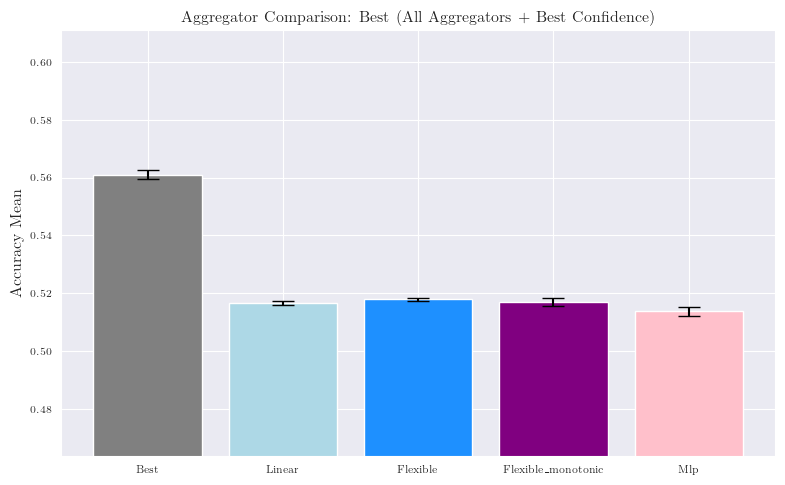

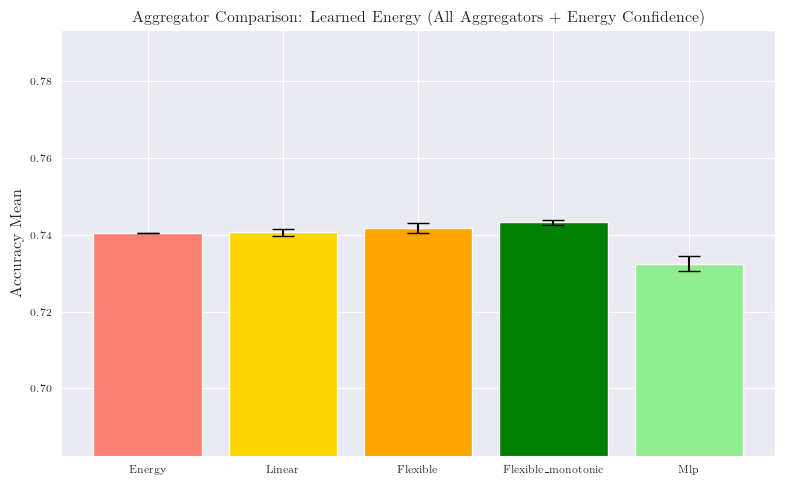

In [76]:
import os
import json
import matplotlib.pyplot as plt

results_dir = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparison_combined")
base_results_dir = os.path.join(
    current_path,
    "experiment_files",
    "results",
    "comparison_unsupervised",
    str(dataset),
    str(architecture),
    getattr(dataset_info, "transform_seq_name", "default"),
)
aggregator_kinds = ["linear", "flexible", "flexible_monotonic", "mlp"]

def load_acc(path):
    if os.path.exists(path):
        with open(path, "r") as f:
            res = json.load(f)
        return res.get("accuracy_mean", 0), res.get("accuracy_se", 0)
    return 0, 0

def load_detector_acc(detector_name):
    eval_path = os.path.join(base_results_dir, detector_name, "eval_results.json")
    eval_default_path = os.path.join(base_results_dir, detector_name, "eval_results_default.json")

    for p in (eval_path, eval_default_path):
        acc, se = load_acc(p)
        if acc != 0:
            return acc, se
    return 0, 0

# --- Plot 1: Best Aggregators + Best Confidence ---
plt.figure(figsize=(8, 5))
labels = ["Best"]
means = []
ses = []

# Add best detector accuracy
best_acc, best_se = load_detector_acc(best_detector)
means.append(best_acc)
ses.append(best_se)

# Add aggregator results
for kind in aggregator_kinds:
    if kind == "mlp":
        path = os.path.join(results_dir, f"{kind}_default.json")
    else:
        path = os.path.join(results_dir, f"{kind}_optimized.json")
    acc, se = load_acc(path)
    labels.append(kind.capitalize())
    means.append(acc)
    ses.append(se)

plt.bar(labels, means, yerr=ses, capsize=8, color=["gray", "lightblue", "dodgerblue", "purple", "pink"])
plt.ylabel("Accuracy Mean")
plt.title("Aggregator Comparison: Best (All Aggregators + Best Confidence)")

# --- Adjust vlim based on min/max ---
ymin = max(0, min(means) - 0.05)
ymax = min(1.0, max(means) + 0.05)
plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()

# --- Plot 2: Energy Aggregators + Energy Confidence ---
plt.figure(figsize=(8, 5))
labels = ["Energy"]
means = []
ses = []
nam = "learned_energy_confidence_transformed.json" if not is_image_data else "learned_energy_confidence_only_blur_aug_transformed.json"

energy_acc_path = os.path.join(
    current_path, "experiment_files", "results", dataset, architecture,
    "comparison_supervised_methods", dataset_info.transform_seq_name, nam
)

# Add energy confidence accuracy
energy_acc, energy_se = load_acc(energy_acc_path)
if energy_se is None:
    energy_se = 0

means.append(energy_acc)
ses.append(energy_se)

# Add aggregator results
for kind in aggregator_kinds:
    if kind == "mlp":
        path = os.path.join(results_dir, f"{kind}_energy_default.json")
    else:
        path = os.path.join(results_dir, f"{kind}_energy_optimized.json")
    acc, se = load_acc(path)
    labels.append(kind.capitalize())
    means.append(acc)
    ses.append(se)

plt.bar(labels, means, yerr=ses, capsize=8, color=["salmon", "gold", "orange", "green", "lightgreen"])
plt.ylabel("Accuracy Mean")
plt.title("Aggregator Comparison: Learned Energy (All Aggregators + Energy Confidence)")

# --- Adjust vlim based on min/max ---
ymin = max(0, min(means) - 0.05)
ymax = min(1.0, max(means) + 0.05)
plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()


In [69]:
print(energy_acc_path)

C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_emnist\bigger_extended_resnet_small\comparison_supervised_methods\bigger_emnist_default\learned_energy_confidence_only_blur_aug_transformed


0

In [ ]:
#plot the results from the comparison_combined folder
import matplotlib.pyplot as plt
import numpy as np
import os